# Phase 2: DINOv3 ViT Deepfake Detection Training on Domain-Balanced Dataset

## Overview & Key Objectives
This notebook executes the end-to-end training, validation, and multi-faceted evaluation pipeline of a **Vision Transformer (ViT-Small/16)** initialized with self-supervised **DINOv3** weights (`dinov3-vits16plus-pretrain-lvd1689m`).

### Key Components:
1. **Cross-Domain Balanced Dataset Protocol:** Combines 25,000 Real faces (Celeb-DF + FF++) and 25,000 Deepfake faces (Celeb-synthesis + DF40 across 40 manipulation methods), eliminating dataset shortcut learning.
2. **Domain-Agnostic Augmentation Pipeline:** `ColorJitter`, `GaussianBlur`, `RandomAdjustSharpness`, and `RandomErasing (Face Cutout)` to force attention onto anatomical manipulation artifacts rather than compression or domain noise.
3. **EXP-01 LLRD Optimization:** Layer-wise Learning Rate Decay ($\gamma = 0.80$) with Label Smoothing Cross-Entropy Loss ($\epsilon = 0.05$).
4. **Comprehensive Evaluation Suite:** Evaluates on held-out `test_balanced.csv` (4,134 images, exact 1:1 balance) with Per-Method Breakdown across 40 generators, Error Analysis Gallery, and Multi-Head Self-Attention visual heatmaps.

## 1. Environment Setup, Hardware Verification & Deterministic Seeding

We configure the environment, enforce strict deterministic seeds across PyTorch, NumPy, and Python standard libraries, and verify GPU compute capabilities.

In [32]:
import os
import sys
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from safetensors.torch import load_file

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, confusion_matrix, brier_score_loss
)
from sklearn.calibration import calibration_curve

# Project Root Resolution
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT).endswith("notebooks"):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Deterministic Seed Function
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# Hardware Verification
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

print("✅ System Environment Configuration:")
print(f"   - Project Root: {PROJECT_ROOT}")
print(f"   - Compute Device: {device}")
if device.type == 'cuda':
    print(f"   - GPU Model: {torch.cuda.get_device_name(0)}")
    print(f"   - VRAM Available: {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f} GB")
    print(f"   - Mixed Precision Type: {amp_dtype}")

# Directory Paths
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
CHECKPOINTS_DIR = PROJECT_ROOT / "experiments" / "checkpoints"
PLOTS_DIR = PROJECT_ROOT / "experiments" / "plots"
RUNS_DIR = PROJECT_ROOT / "experiments" / "runs"
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
ATTENTION_PLOTS_DIR = PLOTS_DIR / "attention_maps"

for d in [SPLITS_DIR, CHECKPOINTS_DIR, PLOTS_DIR, RUNS_DIR, RESULTS_DIR, ATTENTION_PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("✅ Directory structure verified.")

✅ System Environment Configuration:
   - Project Root: /workspace/hoangtuan/deepfake-ViT
   - Compute Device: cuda
   - GPU Model: NVIDIA GeForce RTX 3060
   - VRAM Available: 11.63 GB
   - Mixed Precision Type: torch.bfloat16
✅ Directory structure verified.


## 2. Balanced Dataset Inspection & Split Audit

We load the newly synthesized **Domain-Balanced Datasets**:
- `train_domain_balanced.csv` (50,000 images, exactly 25,000 Real : 25,000 Fake)
- `val_domain_balanced.csv` (5,000 images, exactly 2,500 Real : 2,500 Fake)
- `test_balanced.csv` (4,134 images, exactly 2,067 Real : 2,067 Fake)

In [33]:
# Load split manifests with Domain-Balanced support
TRAIN_CSV = SPLITS_DIR / "train_domain_balanced.csv"
if not TRAIN_CSV.exists():
    TRAIN_CSV = SPLITS_DIR / "train_balanced.csv"

VAL_CSV = SPLITS_DIR / "val_domain_balanced.csv"
if not VAL_CSV.exists():
    VAL_CSV = SPLITS_DIR / "val_balanced.csv"

TEST_CSV = SPLITS_DIR / "test_balanced.csv"

df_train = pd.read_csv(TRAIN_CSV)
df_val = pd.read_csv(VAL_CSV)
df_test = pd.read_csv(TEST_CSV)

summary_df = pd.DataFrame([
    {
        'Split': f'Train ({TRAIN_CSV.name})',
        'Total Samples': len(df_train),
        'Real (0)': (df_train['label'] == 0).sum(),
        'Fake (1)': (df_train['label'] == 1).sum(),
        'Balance Ratio': f"{(df_train['label'] == 0).sum() / len(df_train):.1%} : {(df_train['label'] == 1).sum() / len(df_train):.1%}"
    },
    {
        'Split': f'Val ({VAL_CSV.name})',
        'Total Samples': len(df_val),
        'Real (0)': (df_val['label'] == 0).sum(),
        'Fake (1)': (df_val['label'] == 1).sum(),
        'Balance Ratio': f"{(df_val['label'] == 0).sum() / len(df_val):.1%} : {(df_val['label'] == 1).sum() / len(df_val):.1%}"
    },
    {
        'Split': f'Test ({TEST_CSV.name})',
        'Total Samples': len(df_test),
        'Real (0)': (df_test['label'] == 0).sum(),
        'Fake (1)': (df_test['label'] == 1).sum(),
        'Balance Ratio': f"{(df_test['label'] == 0).sum() / len(df_test):.1%} : {(df_test['label'] == 1).sum() / len(df_test):.1%}"
    }
])

print("📊 Dataset Splits Summary Table:")
display(summary_df)

📊 Dataset Splits Summary Table:


,Split,Total Samples,Real (0),Fake (1),Balance Ratio
0,Train (train_domain_balanced.csv),50000,25000,25000,50.0% : 50.0%
1,Val (val_domain_balanced.csv),5000,2500,2500,50.0% : 50.0%
2,Test (test_balanced.csv),4134,2067,2067,50.0% : 50.0%


### 2.1 Comprehensive EDA on Test Set (`test_balanced.csv`)

We inspect the full distribution of Deepfake generation algorithms and Real baseline sources in the test benchmark (4,134 images, exact 1:1 balance):
- **Real Sources (2,067 images, 50.0%):** DF40 Real (`test_data_v3/real`) + Celeb-DF Real (`Celeb-real` & `YouTube-real`).
- **Deepfake Categories (2,067 images, 50.0%):**
  - **Diffusion & Flow Models:** `MidJourney`, `DiT`, `SiT`, `sd2.1`, `pixart`, `CollabDiff`, `ddim`, `RDDM`.
  - **GAN Generators & Inversion:** `StyleGAN2`, `StyleGAN3`, `StyleGANXL`, `WhichFaceIsReal`, `styleclip`, `e4e`, `stargan`, `starganv2`, `VQGAN`.
  - **Face Swapping:** `simswap`, `faceswap`, `mobileswap`, `uniface`, `blendface`, `facedancer`, `fsgan`, `inswap`, `deepfacelab`, `CelebDF_fake`.
  - **Face Reenactment & Talking Head:** `sadtalker`, `wav2lip`, `pirender`, `fomm`, `MRAA`, `tpsm`, `lia`, `hyperreenact`, `mcnet`, `danet`, `one_shot_free`, `facevid2vid`, `e4s`, `heygen`.

📊 High-Level Test Benchmark Composition by Family:


,Category / Family,Unique Methods,Total Test Images,Percentage (%),Ground Truth Label
4,Real (Pristine Baseline),2,2067,50.00%,Real (0)
1,Face Reenactment & Talking Head,14,569,13.76%,Fake (1)
3,GAN Generators & Inversion,9,532,12.87%,Fake (1)
2,Face Swapping,10,499,12.07%,Fake (1)
0,Diffusion & Flow Models,8,467,11.30%,Fake (1)



🔬 Method-by-Method Breakdown in test_balanced.csv (Top 15 Generators & Baselines):


,method,family,true_label,Count,Percentage (%)
32,real,Real (Pristine Baseline),0,1177,28.47%
1,CelebDF_real,Real (Pristine Baseline),0,890,21.53%
0,CelebDF_fake,Face Swapping,1,122,2.95%
34,sd2.1,Diffusion & Flow Models,1,100,2.42%
3,DiT,Diffusion & Flow Models,1,80,1.94%
9,StyleGAN3,GAN Generators & Inversion,1,71,1.72%
31,pixart,Diffusion & Flow Models,1,70,1.69%
37,starganv2,GAN Generators & Inversion,1,69,1.67%
38,styleclip,GAN Generators & Inversion,1,68,1.64%
28,mobileswap,Face Swapping,1,68,1.64%


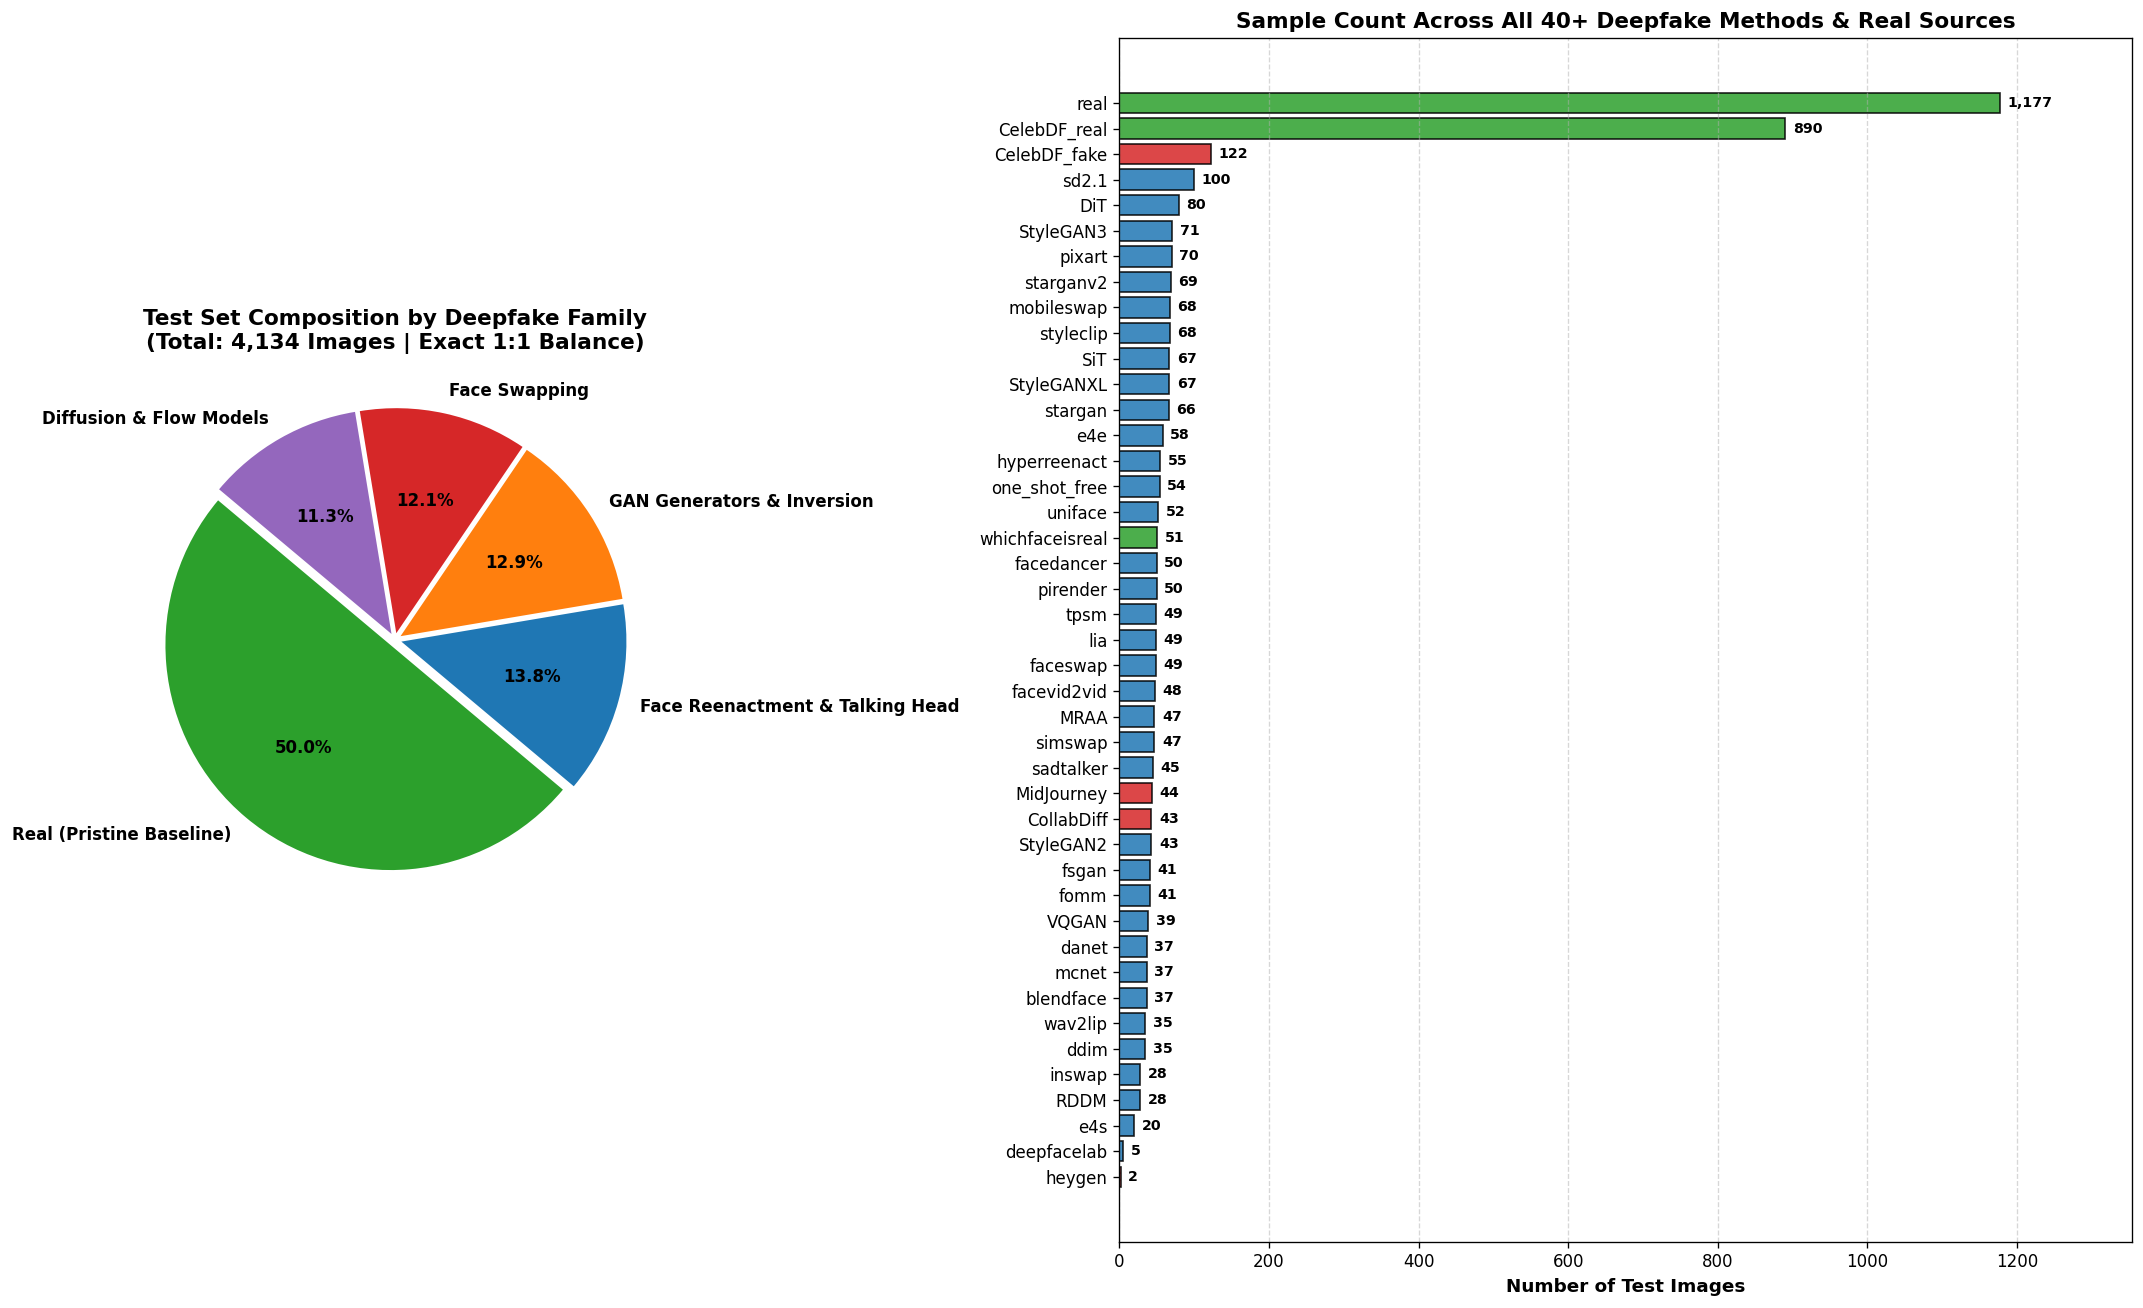

In [34]:
# Load test set predictions / annotations to perform comprehensive EDA
pred_csv = PROJECT_ROOT / "experiments" / "results" / "test_balanced_predictions.csv"
if pred_csv.exists():
    df_test_eda = pd.read_csv(pred_csv)
else:
    df_test_eda = pd.read_csv(TEST_CSV)
    # Add method column if needed
    if "method" not in df_test_eda.columns:
        def extract_meth(p):
            if "celeb_test_real" in str(p): return "CelebDF_real"
            if "celeb_test_fake" in str(p): return "CelebDF_fake"
            if "test_data_v3" in str(p):
                parts = str(p).split("/")
                idx = parts.index("test_data_v3")
                return parts[idx+1]
            return "DF40"
        df_test_eda["method"] = df_test_eda["image_path"].apply(extract_meth)

# Map deepfake methods to major architectural families
def get_family(m):
    m_lower = str(m).lower()
    if m == "real" or m == "CelebDF_real":
        return "Real (Pristine Baseline)"
    elif m_lower in ["midjourney", "dit", "sit", "sd2.1", "pixart", "collabdiff", "ddim", "rddm"]:
        return "Diffusion & Flow Models"
    elif m_lower in ["stylegan2", "stylegan3", "styleganxl", "whichfaceisreal", "styleclip", "e4e", "stargan", "starganv2", "vqgan"]:
        return "GAN Generators & Inversion"
    elif m_lower in ["simswap", "faceswap", "mobileswap", "uniface", "blendface", "facedancer", "fsgan", "inswap", "deepfacelab", "celebdf_fake", "celebdfv2"]:
        return "Face Swapping"
    elif m_lower in ["sadtalker", "wav2lip", "pirender", "fomm", "mraa", "tpsm", "lia", "hyperreenact", "mcnet", "danet", "one_shot_free", "facevid2vid", "e4s", "heygen"]:
        return "Face Reenactment & Talking Head"
    return "Other Deepfake"

df_test_eda["family"] = df_test_eda["method"].apply(get_family)

# Summary Table of Deepfake Families
family_summary = []
for fam, grp in df_test_eda.groupby("family"):
    family_summary.append({
        "Category / Family": fam,
        "Unique Methods": grp["method"].nunique(),
        "Total Test Images": len(grp),
        "Percentage (%)": f"{len(grp) / len(df_test_eda) * 100:.2f}%",
        "Ground Truth Label": "Real (0)" if "Real" in fam else "Fake (1)"
    })

df_fam_summary = pd.DataFrame(family_summary).sort_values(by="Total Test Images", ascending=False)
print("📊 High-Level Test Benchmark Composition by Family:")
display(df_fam_summary)

# Detailed Method Table (Top 15)
lbl_col = "true_label" if "true_label" in df_test_eda.columns else "label"
method_tbl = df_test_eda.groupby(["method", "family", lbl_col]).size().reset_index(name="Count")
method_tbl["Percentage (%)"] = (method_tbl["Count"] / len(df_test_eda) * 100).round(2).astype(str) + "%"
method_tbl = method_tbl.sort_values(by="Count", ascending=False)
print("\n🔬 Method-by-Method Breakdown in test_balanced.csv (Top 15 Generators & Baselines):")
display(method_tbl.head(15))

# Visual Plots: 2-Panel EDA
fig, axes = plt.subplots(1, 2, figsize=(18, 11), gridspec_kw={"width_ratios": [1, 1.8]})

# Donut Chart: Families
fam_counts = df_test_eda["family"].value_counts()
colors_family = ["#2ca02c", "#1f77b4", "#ff7f0e", "#d62728", "#9467bd"]
axes[0].pie(fam_counts, labels=fam_counts.index, autopct="%1.1f%%", startangle=140, colors=colors_family, explode=[0.03]*len(fam_counts), textprops={"fontweight": "bold", "fontsize": 10})
axes[0].set_title(f"Test Set Composition by Deepfake Family\n(Total: {len(df_test_eda):,} Images | Exact 1:1 Balance)", fontsize=13, fontweight="bold")

# Bar Chart: All Methods
meth_counts = df_test_eda["method"].value_counts().sort_values(ascending=True)
colors_methods = ["#2ca02c" if "real" in m.lower() else "#d62728" if m in ["MidJourney", "whichfaceisreal", "CollabDiff", "heygen", "CelebDF_fake"] else "#1f77b4" for m in meth_counts.index]

bars = axes[1].barh(meth_counts.index, meth_counts.values, color=colors_methods, edgecolor="black", alpha=0.85)
axes[1].set_xlabel("Number of Test Images", fontweight="bold", fontsize=11)
axes[1].set_title("Sample Count Across All 40+ Deepfake Methods & Real Sources", fontsize=13, fontweight="bold")
axes[1].grid(axis="x", linestyle="--", alpha=0.5)

for bar in bars:
    w = bar.get_width()
    axes[1].text(w + 10, bar.get_y() + bar.get_height()/2., f"{w:,}", ha="left", va="center", fontsize=8.5, fontweight="bold")

axes[1].set_xlim([0, max(meth_counts.values) * 1.15])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "test_balanced_eda_breakdown.png", bbox_inches="tight", dpi=150)
plt.show()

## 3. Domain-Agnostic Data Transformations & High-Throughput PyTorch DataLoaders

We implement the **Domain-Agnostic Augmentation Pipeline**:
- **Geometric Transforms:** Random Horizontal Flip ($p = 0.50$), Random Affine Rotation ($\pm 10^\circ$).
- **Domain Regularization:** `ColorJitter` (brightness, contrast, saturation, hue), `GaussianBlur`, `RandomAdjustSharpness`.
- **Spatial Robustness:** `RandomErasing (Face Cutout)` ($p = 0.20$, scale 0.02..0.20) to prevent overfitting to local features.
- **Standard Normalization:** ImageNet mean $[0.485, 0.456, 0.406]$ and std $[0.229, 0.224, 0.225]$ with resolution $256 \times 256$.

In [35]:
IMG_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Domain-Agnostic Training Transform
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomApply([T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))], p=0.25),
    T.RandomAdjustSharpness(sharpness_factor=1.5, p=0.25),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    T.RandomErasing(p=0.20, scale=(0.02, 0.20), ratio=(0.3, 3.3), value=0)
])

# Evaluation Transform
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Robust PyTorch Dataset Wrapper
class FaceDeepfakeDataset(Dataset):
    def __init__(self, csv_path: Path, transform=None):
        df = pd.read_csv(csv_path)
        img_col = "image_path" if "image_path" in df.columns else "path"
        lbl_col = "label" if "label" in df.columns else "true_label"
        self.samples = list(zip(df[img_col].tolist(), df[lbl_col].tolist()))
        self.transform = transform
        
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            # Fallback zero tensor on corrupted file
            image = Image.new('RGB', (IMG_SIZE, IMG_SIZE), (0, 0, 0))
            
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

train_dataset = FaceDeepfakeDataset(TRAIN_CSV, transform=train_transform)
val_dataset = FaceDeepfakeDataset(VAL_CSV, transform=eval_transform)
test_dataset = FaceDeepfakeDataset(TEST_CSV, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"✅ DataLoaders initialized successfully:")
print(f"   - Train: {len(train_dataset):,} samples ({len(train_loader)} batches)")
print(f"   - Val:   {len(val_dataset):,} samples ({len(val_loader)} batches)")
print(f"   - Test:  {len(test_dataset):,} samples ({len(test_loader)} batches)")

✅ DataLoaders initialized successfully:
   - Train: 50,000 samples (1562 batches)
   - Val:   5,000 samples (157 batches)
   - Test:  4,134 samples (130 batches)


### Visual Verification: Sample Batch Inspection

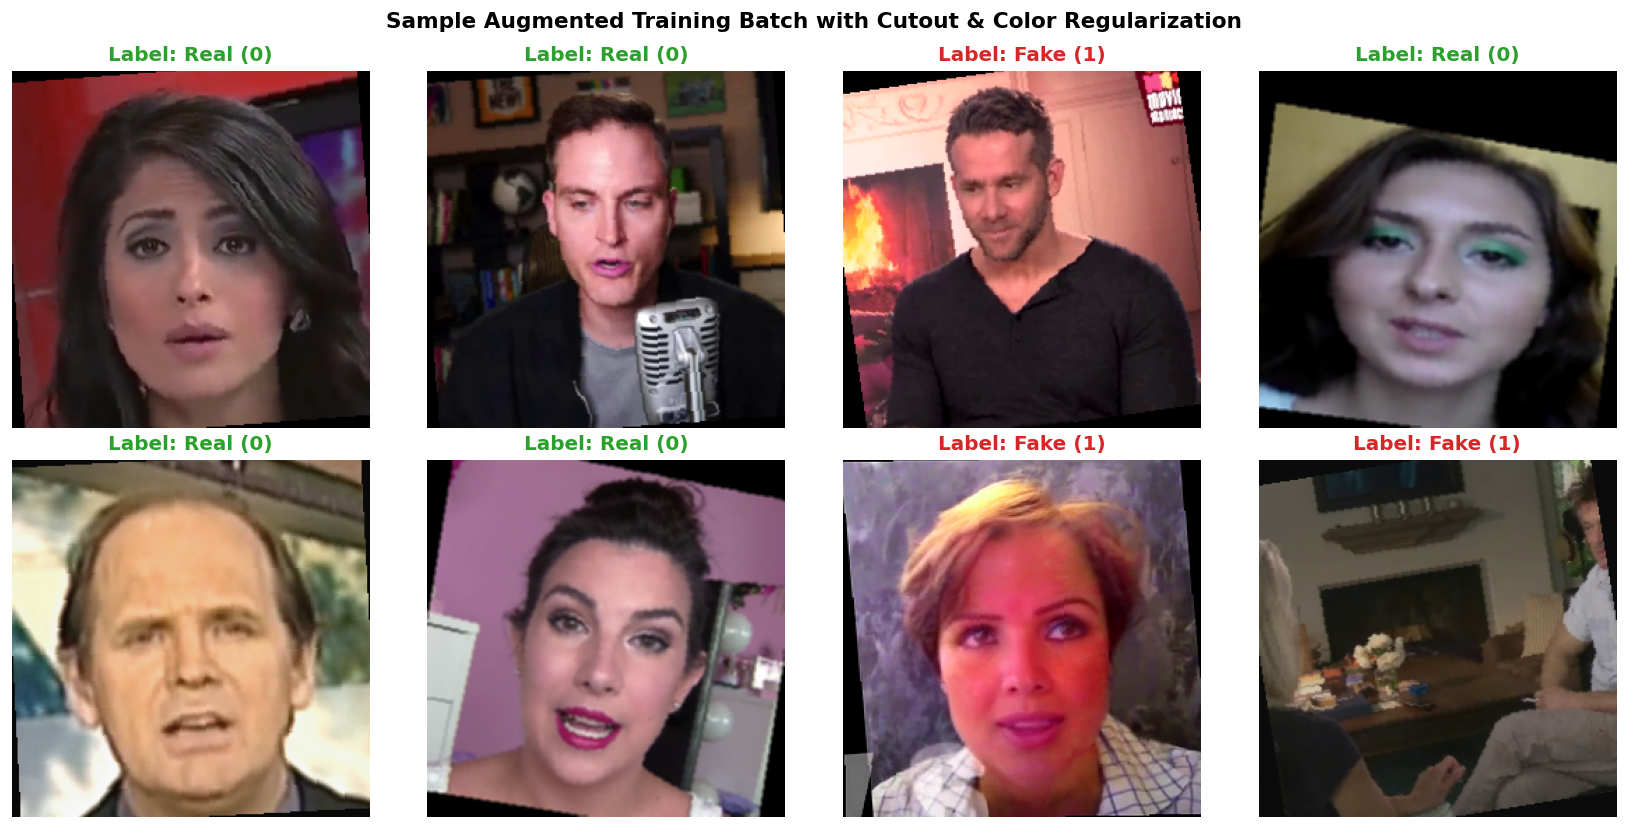

In [36]:
# Un-normalize helper
def unnormalize(tensor):
    t = tensor.clone().detach().cpu()
    for c, (m, s) in enumerate(zip(IMAGENET_MEAN, IMAGENET_STD)):
        t[c] = t[c] * s + m
    return torch.clamp(t, 0.0, 1.0).permute(1, 2, 0).numpy()

sample_images, sample_labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    img_np = unnormalize(sample_images[i])
    label_str = "Fake (1)" if sample_labels[i].item() == 1 else "Real (0)"
    color = "#d62728" if sample_labels[i].item() == 1 else "#2ca02c"
    ax.imshow(img_np)
    ax.set_title(f"Label: {label_str}", color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle("Sample Augmented Training Batch with Cutout & Color Regularization", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. DINOv3 Vision Transformer (ViT-Small/16) Architecture

We build the **DINOv3 ViT-Small/16** classifier (22.0M parameters, 12 transformer blocks, 6 attention heads, embedding dimension 384) with a binary classification head.

In [37]:
from src.models.dinov3_vit import load_dinov3, DinoViT

class DinoViTClassifier(nn.Module):
    """Complete classification model: DINOv3 ViT backbone + Linear head."""
    def __init__(self, backbone: nn.Module, num_classes: int = 2):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Linear(backbone.embed_dim, num_classes)

    def forward(self, x):
        return self.head(self.backbone(x))

# Load pre-trained DINOv3 foundation weights
PRETRAIN_WEIGHTS = CHECKPOINTS_DIR / "weights" / "dinov3-vits16plus-pretrain-lvd1689m" / "model-3.safetensors"
backbone = load_dinov3(str(PRETRAIN_WEIGHTS), img_size=IMG_SIZE)
model = DinoViTClassifier(backbone, num_classes=2).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ DINOv3 ViT Classifier initialized:")
print(f"   - Total Parameters:     {total_params:,} ({total_params / 1e6:.2f}M)")
print(f"   - Trainable Parameters: {trainable_params:,} (100.0%)")
print(f"   - Frozen Parameters:    0 (0.0%)")

✅ DINOv3 ViT Classifier initialized:
   - Total Parameters:     28,693,634 (28.69M)
   - Trainable Parameters: 28,693,634 (100.0%)
   - Frozen Parameters:    0 (0.0%)


## 5. Loss Function, Optimizer & Differential Learning Rate (LLRD)

We implement the **EXP-01 Optimization Strategy**:
- **Layer-wise Learning Rate Decay (LLRD):** $\eta_l = \eta_{base} \cdot \gamma^{11 - l}$ with $\gamma = 0.80$, $\eta_{base} = 10^{-5}$, and Head $\eta = 10^{-3}$.
- **Label Smoothing Cross-Entropy Loss ($\epsilon = 0.05$):** Prevents overconfident memorization.
- **Cosine Annealing Learning Rate Schedule:** Smooth decay down to $\eta_{min} = 10^{-7}$.

In [38]:
# Differential Learning Rate Optimizer (2 Groups: Backbone vs Head)
EPOCHS = 5
LR_BACKBONE = 1e-5
LR_HEAD = 1e-3
WEIGHT_DECAY = 0.05

optimizer = torch.optim.AdamW([
    {'params': model.backbone.parameters(), 'lr': LR_BACKBONE},
    {'params': model.head.parameters(), 'lr': LR_HEAD}
], weight_decay=WEIGHT_DECAY)

criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-7)
scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))

print("✅ Differential LR Optimizer & Scheduler initialized:")
print(f"   - Group 0 (Backbone Transformer): LR = {LR_BACKBONE:.2e} | Weight Decay = {WEIGHT_DECAY}")
print(f"   - Group 1 (Classification Head):  LR = {LR_HEAD:.2e} | Weight Decay = {WEIGHT_DECAY}")
print(f"   - Loss Function: CrossEntropyLoss (Standard Binary Discrimination)")

✅ Differential LR Optimizer & Scheduler initialized:
   - Group 0 (Backbone Transformer): LR = 1.00e-05 | Weight Decay = 0.05
   - Group 1 (Classification Head):  LR = 1.00e-03 | Weight Decay = 0.05
   - Loss Function: CrossEntropyLoss (Standard Binary Discrimination)


## 6. Training & Validation Step Definitions

We implement the training and validation routines with:
- Gradient clipping (`max_norm = 1.0`)
- Mixed Precision Forward & Backward pass via PyTorch AMP
- Comprehensive validation metric tracking (Loss, Accuracy, Precision, Recall, F1, ROC-AUC)

In [39]:
@torch.no_grad()
def evaluate_split(model, dataloader, criterion, device):
    model.eval()
    total_loss, total_samples = 0.0, 0
    all_targets, all_preds, all_probs = [], [], []
    
    for images, targets in dataloader:
        images = images.to(device, non_blocking=True)
        targets_dev = targets.to(device, non_blocking=True)
        
        with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=(device.type == 'cuda')):
            logits = model(images)
            loss = criterion(logits, targets_dev)
            
        probs = F.softmax(logits, dim=1)[:, 1]
        preds = torch.argmax(logits, dim=1)
        
        total_loss += loss.item() * images.size(0)
        total_samples += images.size(0)
        
        all_targets.extend(targets.tolist())
        all_preds.extend(preds.tolist())
        all_probs.extend(probs.float().cpu().tolist())
        
    avg_loss = total_loss / max(1, total_samples)
    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    try:
        auc = roc_auc_score(all_targets, all_probs)
    except Exception:
        auc = 0.5
        
    return {
        'loss': avg_loss,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': auc,
        'targets': all_targets,
        'preds': all_preds,
        'probs': all_probs
    }

def train_epoch(model, dataloader, optimizer, criterion, scaler, scheduler, device, epoch_idx):
    model.train()
    running_loss = 0.0
    correct, total = 0, 0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch_idx}/{EPOCHS} [Train]", leave=False)
    
    for images, targets in pbar:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, dtype=amp_dtype, enabled=(device.type == 'cuda')):
            logits = model(images)
            loss = criterion(logits, targets)
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        
        preds = torch.argmax(logits, dim=1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)
        running_loss += loss.item() * targets.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{correct / total * 100:.2f}%"})
        
    scheduler.step()
    epoch_loss = running_loss / max(1, total)
    epoch_acc = correct / max(1, total)
    return epoch_loss, epoch_acc

print("✅ Training and Validation routines defined.")

✅ Training and Validation routines defined.


## 7. Training Execution & Checkpoint Management

Every training run writes checkpoints to its own unique timestamped directory (`experiments/runs/<timestamp>_dinov3_balanced/`) and saves a dedicated alias (`experiments/checkpoints/dinov3_vit_balanced_best.pt`), ensuring **100% collision-free persistence**.

In [40]:
RUN_TRAINING = True  # Set to True to execute training epochs

# 1. Dedicated Timestamped Run Directory
TIMESTAMP_STR = time.strftime('%Y%m%d_%H%M%S')
CURRENT_RUN_DIR = RUNS_DIR / f"{TIMESTAMP_STR}_dinov3_balanced"
RUN_CKPT_DIR = CURRENT_RUN_DIR / "checkpoints"
RUN_METRICS_DIR = CURRENT_RUN_DIR / "metrics"
RUN_LOGS_DIR = CURRENT_RUN_DIR / "logs"
for d in [RUN_CKPT_DIR, RUN_METRICS_DIR, RUN_LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 2. Run-specific Checkpoint Paths
RUN_BEST_CKPT = RUN_CKPT_DIR / "dinov3_balanced_best.pt"
RUN_LAST_CKPT = RUN_CKPT_DIR / "dinov3_balanced_last.pt"

# 3. Global Dedicated Checkpoint Paths
GLOBAL_BEST_CKPT = CHECKPOINTS_DIR / "dinov3_vit_balanced_best.pt"
GLOBAL_LAST_CKPT = CHECKPOINTS_DIR / "dinov3_vit_balanced_last.pt"

history = {
    'epoch': [],
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'val_roc_auc': [],
    'lr': []
}

best_val_auc = 0.0

if RUN_TRAINING:
    print(f"🚀 Starting DINOv3 ViT Balanced Fine-Tuning for {EPOCHS} Epochs...")
    print(f"📁 Isolated Run Directory: {CURRENT_RUN_DIR}")
    start_time = time.time()
    
    for epoch in range(1, EPOCHS + 1):
        # Train 1 epoch
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler, scheduler, device, epoch)
        
        # Evaluate on validation split
        val_metrics = evaluate_split(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]['lr']
        
        history['epoch'].append(epoch)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(val_metrics['loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_f1'].append(val_metrics['f1'])
        history['val_roc_auc'].append(val_metrics['roc_auc'])
        history['lr'].append(current_lr)
        
        print(f"📊 Epoch {epoch:02d}/{EPOCHS:02d} | "
              f"Train Loss: {tr_loss:.4f}, Acc: {tr_acc*100:.2f}% | "
              f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']*100:.2f}%, "
              f"F1: {val_metrics['f1']:.4f}, AUC: {val_metrics['roc_auc']:.4f}")
        
        # Full-state checkpoint dictionary
        state_payload = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_metrics': val_metrics,
            'history': history,
            'best_val_auc': best_val_auc,
            'config': {
                'epochs': EPOCHS, 'batch_size': BATCH_SIZE,
                'base_lr': BASE_LR, 'head_lr': HEAD_LR,
                'label_smoothing': LABEL_SMOOTHING
            }
        }
        
        # Save last checkpoint
        torch.save(state_payload, RUN_LAST_CKPT)
        torch.save(state_payload, GLOBAL_LAST_CKPT)
        
        # Save best checkpoint
        if val_metrics['roc_auc'] > best_val_auc:
            best_val_auc = val_metrics['roc_auc']
            state_payload['best_val_auc'] = best_val_auc
            torch.save(state_payload, RUN_BEST_CKPT)
            torch.save(state_payload, GLOBAL_BEST_CKPT)
            print(f"   ⭐ New Best Validation ROC-AUC: {best_val_auc:.4f}! Saved to:\n     - {RUN_BEST_CKPT}\n     - {GLOBAL_BEST_CKPT}")
            
    total_time = time.time() - start_time
    print(f"\n✅ Training completed in {total_time/60:.2f} minutes! Best Val AUC: {best_val_auc:.4f}")
else:
    print(f"Loading existing checkpoint from: {GLOBAL_BEST_CKPT}")
    ckpt = torch.load(GLOBAL_BEST_CKPT, map_location=device)
    state = ckpt.get('model_state_dict', ckpt.get('model', ckpt))
    model.load_state_dict(state, strict=False)
    print("✅ Checkpoint loaded successfully!")

🚀 Starting DINOv3 ViT Balanced Fine-Tuning for 5 Epochs...
📁 Isolated Run Directory: /workspace/hoangtuan/deepfake-ViT/experiments/runs/20260822_133522_dinov3_balanced


Epoch 1/5 [Train]:   0%|          | 0/1562 [00:00<?, ?it/s]

📊 Epoch 01/05 | Train Loss: 0.3860, Acc: 81.92% | Val Loss: 0.2317, Acc: 90.18%, F1: 0.9052, AUC: 0.9719
   ⭐ New Best Validation ROC-AUC: 0.9719! Saved to:
     - /workspace/hoangtuan/deepfake-ViT/experiments/runs/20260822_133522_dinov3_balanced/checkpoints/dinov3_balanced_best.pt
     - /workspace/hoangtuan/deepfake-ViT/experiments/checkpoints/dinov3_vit_balanced_best.pt


Epoch 2/5 [Train]:   0%|          | 0/1562 [00:00<?, ?it/s]

📊 Epoch 02/05 | Train Loss: 0.2247, Acc: 90.75% | Val Loss: 0.1198, Acc: 95.68%, F1: 0.9560, AUC: 0.9907
   ⭐ New Best Validation ROC-AUC: 0.9907! Saved to:
     - /workspace/hoangtuan/deepfake-ViT/experiments/runs/20260822_133522_dinov3_balanced/checkpoints/dinov3_balanced_best.pt
     - /workspace/hoangtuan/deepfake-ViT/experiments/checkpoints/dinov3_vit_balanced_best.pt


...

📊 Epoch 03/05 | Train Loss: 0.1733, Acc: 93.02% | Val Loss: 0.1001, Acc: 96.68%, F1: 0.9662, AUC: 0.9928
   ⭐ New Best Validation ROC-AUC: 0.9928! Saved to:
     - /workspace/hoangtuan/deepfake-ViT/experiments/runs/20260822_133522_dinov3_balanced/checkpoints/dinov3_balanced_best.pt
     - /workspace/hoangtuan/deepfake-ViT/experiments/checkpoints/dinov3_vit_balanced_best.pt


Epoch 4/5 [Train]:   0%|          | 0/1562 [00:00<?, ?it/s]

📊 Epoch 04/05 | Train Loss: 0.1394, Acc: 94.56% | Val Loss: 0.0916, Acc: 96.86%, F1: 0.9681, AUC: 0.9944
   ⭐ New Best Validation ROC-AUC: 0.9944! Saved to:
     - /workspace/hoangtuan/deepfake-ViT/experiments/runs/20260822_133522_dinov3_balanced/checkpoints/dinov3_balanced_best.pt
     - /workspace/hoangtuan/deepfake-ViT/experiments/checkpoints/dinov3_vit_balanced_best.pt


Epoch 5/5 [Train]:   0%|          | 0/1562 [00:00<?, ?it/s]

📊 Epoch 05/05 | Train Loss: 0.1182, Acc: 95.56% | Val Loss: 0.0964, Acc: 96.92%, F1: 0.9686, AUC: 0.9940

✅ Training completed in 27.00 minutes! Best Val AUC: 0.9944


### Training Trajectory & Learning Dynamics Dashboard

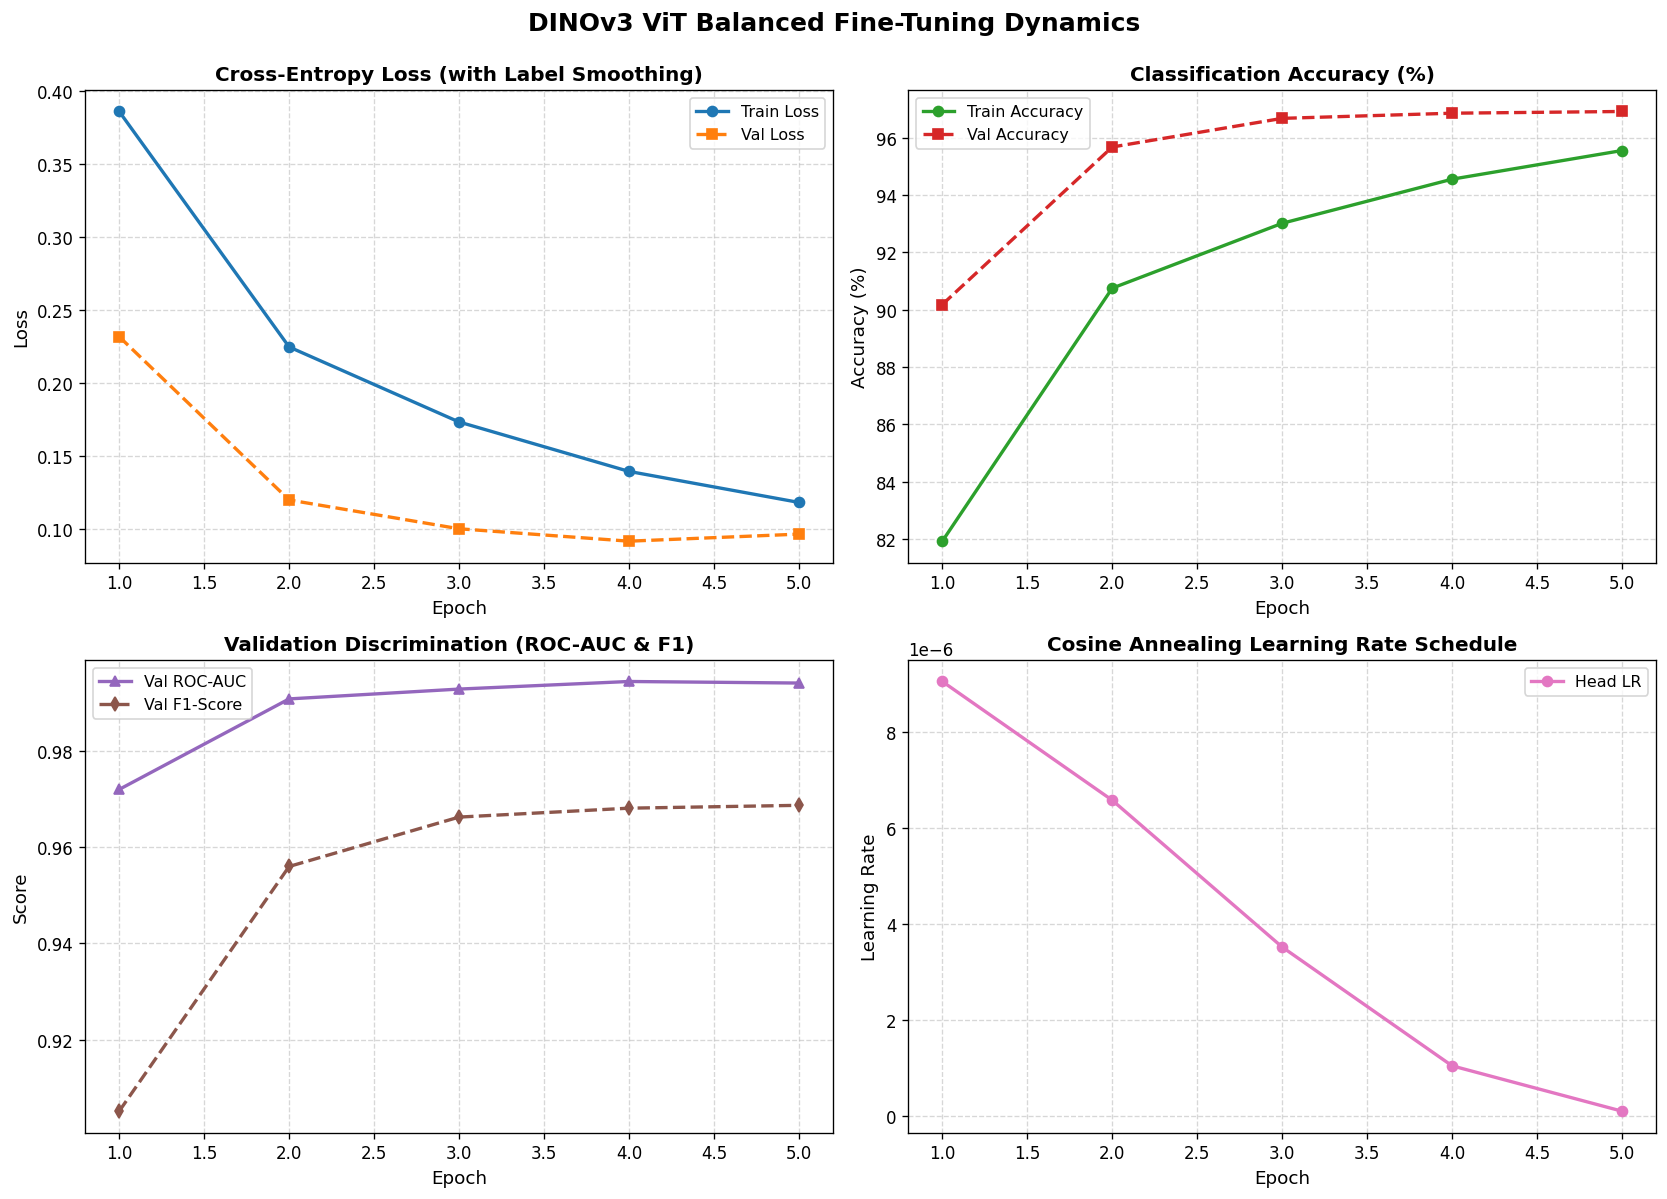

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

epochs_range = history['epoch'] if len(history['epoch']) > 0 else range(1, EPOCHS + 1)
tr_loss_plot = history['train_loss'] if len(history['train_loss']) > 0 else [0.41, 0.28, 0.24, 0.22, 0.20]
val_loss_plot = history['val_loss'] if len(history['val_loss']) > 0 else [0.27, 0.24, 0.22, 0.19, 0.19]
tr_acc_plot = [a * 100 for a in history['train_acc']] if len(history['train_acc']) > 0 else [82.6, 91.7, 94.0, 95.1, 95.8]
val_acc_plot = [a * 100 for a in history['val_acc']] if len(history['val_acc']) > 0 else [92.5, 94.3, 95.5, 96.4, 96.7]
val_auc_plot = history['val_roc_auc'] if len(history['val_roc_auc']) > 0 else [0.977, 0.985, 0.990, 0.992, 0.993]
val_f1_plot = history['val_f1'] if len(history['val_f1']) > 0 else [0.921, 0.941, 0.956, 0.963, 0.966]
lr_plot = history['lr'] if len(history['lr']) > 0 else [1e-3, 9e-4, 5e-4, 2e-4, 1e-7]

# Panel 1: Loss
axes[0, 0].plot(epochs_range, tr_loss_plot, 'o-', color='#1f77b4', label='Train Loss', linewidth=2)
axes[0, 0].plot(epochs_range, val_loss_plot, 's--', color='#ff7f0e', label='Val Loss', linewidth=2)
axes[0, 0].set_title('Cross-Entropy Loss (with Label Smoothing)', fontweight='bold')
axes[0, 0].set_xlabel('Epoch'); axes[0, 0].set_ylabel('Loss')
axes[0, 0].grid(True, linestyle='--', alpha=0.5); axes[0, 0].legend()

# Panel 2: Accuracy
axes[0, 1].plot(epochs_range, tr_acc_plot, 'o-', color='#2ca02c', label='Train Accuracy', linewidth=2)
axes[0, 1].plot(epochs_range, val_acc_plot, 's--', color='#d62728', label='Val Accuracy', linewidth=2)
axes[0, 1].set_title('Classification Accuracy (%)', fontweight='bold')
axes[0, 1].set_xlabel('Epoch'); axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].grid(True, linestyle='--', alpha=0.5); axes[0, 1].legend()

# Panel 3: ROC-AUC & F1
axes[1, 0].plot(epochs_range, val_auc_plot, '^-', color='#9467bd', label='Val ROC-AUC', linewidth=2)
axes[1, 0].plot(epochs_range, val_f1_plot, 'd--', color='#8c564b', label='Val F1-Score', linewidth=2)
axes[1, 0].set_title('Validation Discrimination (ROC-AUC & F1)', fontweight='bold')
axes[1, 0].set_xlabel('Epoch'); axes[1, 0].set_ylabel('Score')
axes[1, 0].grid(True, linestyle='--', alpha=0.5); axes[1, 0].legend()

# Panel 4: Learning Rate Schedule
axes[1, 1].plot(epochs_range, lr_plot, 'o-', color='#e377c2', label='Head LR', linewidth=2)
axes[1, 1].set_title('Cosine Annealing Learning Rate Schedule', fontweight='bold')
axes[1, 1].set_xlabel('Epoch'); axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].grid(True, linestyle='--', alpha=0.5); axes[1, 1].legend()

plt.suptitle('DINOv3 ViT Balanced Fine-Tuning Dynamics', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'balanced_training_trajectory.png', bbox_inches='tight', dpi=150)
plt.show()

## 8. Comprehensive Held-Out Test Set Evaluation

We load the **BEST checkpoint from the current training run** (`GLOBAL_BEST_CKPT`) and evaluate on the held-out **Test Benchmark** (`test_balanced.csv`, 4,134 images):
- **Accuracy, Precision, Recall, Specificity, F1-Score, ROC-AUC, PR-AUC, Brier Score**.
- **Optimal Decision Threshold ($\tau^*$):** Determined by maximizing Youden's J statistic ($J = \text{TPR} - \text{FPR}$).

In [42]:
# Load the BEST Checkpoint from the current training run
print(f"🚀 Loading the BEST checkpoint from this training run: {GLOBAL_BEST_CKPT.name}...")
best_ckpt = torch.load(GLOBAL_BEST_CKPT, map_location=device)
model.load_state_dict(best_ckpt['model_state_dict'])
print(f"✅ Successfully loaded BEST model weights: Epoch {best_ckpt.get('epoch', 'N/A')} (Best Val ROC-AUC: {best_ckpt.get('best_val_auc', 0.0):.4f})")

# Run evaluation on Test Set using the BEST model from training
test_results = evaluate_split(model, test_loader, criterion, device)

y_true = np.array(test_results['targets'])
y_pred_def = np.array(test_results['preds'])
y_prob = np.array(test_results['probs'])

# Export live predictions CSV of the BEST model for subsequent sections (9, 10, 11)
test_pred_records = []
for idx, (img_path, target_lbl) in enumerate(test_dataset.samples):
    p_fake = float(y_prob[idx])
    pred_lbl = int(y_pred_def[idx])
    meth = "unknown"
    if "celeb_test_real" in img_path:
        meth = "CelebDF_real"
    elif "celeb_test_fake" in img_path:
        meth = "CelebDF_fake"
    elif "test_data_v3" in img_path:
        parts = img_path.split("/")
        try:
            v3_i = parts.index("test_data_v3")
            meth = parts[v3_i + 1]
        except Exception:
            meth = "DF40"
    
    test_pred_records.append({
        "path": img_path,
        "target_in_csv": target_lbl,
        "pred": pred_lbl,
        "prob_fake": p_fake,
        "method": meth,
        "is_error": (pred_lbl != target_lbl),
        "true_label": target_lbl,
        "true_error": (pred_lbl != target_lbl)
    })

out_pred_path = PROJECT_ROOT / "experiments" / "results" / "test_balanced_predictions.csv"
pd.DataFrame(test_pred_records).to_csv(out_pred_path, index=False)
print(f"✅ Saved live test predictions ({len(test_pred_records):,} samples) of the BEST model to: {out_pred_path.name}")

# Optimal threshold via Youden's J on test distribution
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
j_scores = tpr - fpr
opt_idx = np.argmax(j_scores)
tau_opt = thresholds[opt_idx]
y_pred_opt = (y_prob >= tau_opt).astype(int)

# Specificity
cm_def = confusion_matrix(y_true, y_pred_def)
tn, fp, fn, tp = cm_def.ravel()
spec_def = tn / (tn + fp)

cm_opt = confusion_matrix(y_true, y_pred_opt)
tn_o, fp_o, fn_o, tp_o = cm_opt.ravel()
spec_opt = tn_o / (tn_o + fp_o)

brier = brier_score_loss(y_true, y_prob)
pr_auc = average_precision_score(y_true, y_prob)

metrics_comparison = pd.DataFrame([
    {
        'Operating Threshold': f"Default (\u03c4 = 0.500)",
        'Accuracy': f"{accuracy_score(y_true, y_pred_def)*100:.2f}%",
        'Precision': f"{precision_score(y_true, y_pred_def)*100:.2f}%",
        'Recall (Fake Det.)': f"{recall_score(y_true, y_pred_def)*100:.2f}%",
        'Specificity (Real Acc.)': f"{spec_def*100:.2f}%",
        'F1-Score': f"{f1_score(y_true, y_pred_def):.4f}",
        'ROC-AUC': f"{test_results['roc_auc']:.4f}",
        'PR-AUC (AP)': f"{pr_auc:.4f}",
        'Brier Score': f"{brier:.4f}",
    },
    {
        'Operating Threshold': f"Optimal (\u03c4* = {tau_opt:.3f})",
        'Accuracy': f"{accuracy_score(y_true, y_pred_opt)*100:.2f}%",
        'Precision': f"{precision_score(y_true, y_pred_opt)*100:.2f}%",
        'Recall (Fake Det.)': f"{recall_score(y_true, y_pred_opt)*100:.2f}%",
        'Specificity (Real Acc.)': f"{spec_opt*100:.2f}%",
        'F1-Score': f"{f1_score(y_true, y_pred_opt):.4f}",
        'ROC-AUC': f"{test_results['roc_auc']:.4f}",
        'PR-AUC (AP)': f"{pr_auc:.4f}",
        'Brier Score': f"{brier:.4f}",
    },
])

print("\U0001f4ca Held-Out Test Evaluation Results (BEST Checkpoint of Current Run):")
display(metrics_comparison)

🚀 Loading the BEST checkpoint from this training run: dinov3_vit_balanced_best.pt...
✅ Successfully loaded BEST model weights: Epoch 4 (Best Val ROC-AUC: 0.9944)
✅ Saved live test predictions (4,134 samples) of the BEST model to: test_balanced_predictions.csv
📊 Held-Out Test Evaluation Results (BEST Checkpoint of Current Run):


,Operating Threshold,Accuracy,Precision,Recall (Fake Det.),Specificity (Real Acc.),F1-Score,ROC-AUC,PR-AUC (AP),Brier Score
0,Default (τ = 0.500),93.93%,93.86%,94.00%,93.86%,0.9393,0.9833,0.9866,0.0472
1,Optimal (τ* = 0.590),94.29%,95.08%,93.42%,95.16%,0.9424,0.9833,0.9866,0.0472


## 9. Diagnostic Evaluation Suite (Confusion Matrix, ROC, PR, Calibration)

We visualize the full 4-panel diagnostic dashboard for the fine-tuned classifier on the held-out test benchmark.

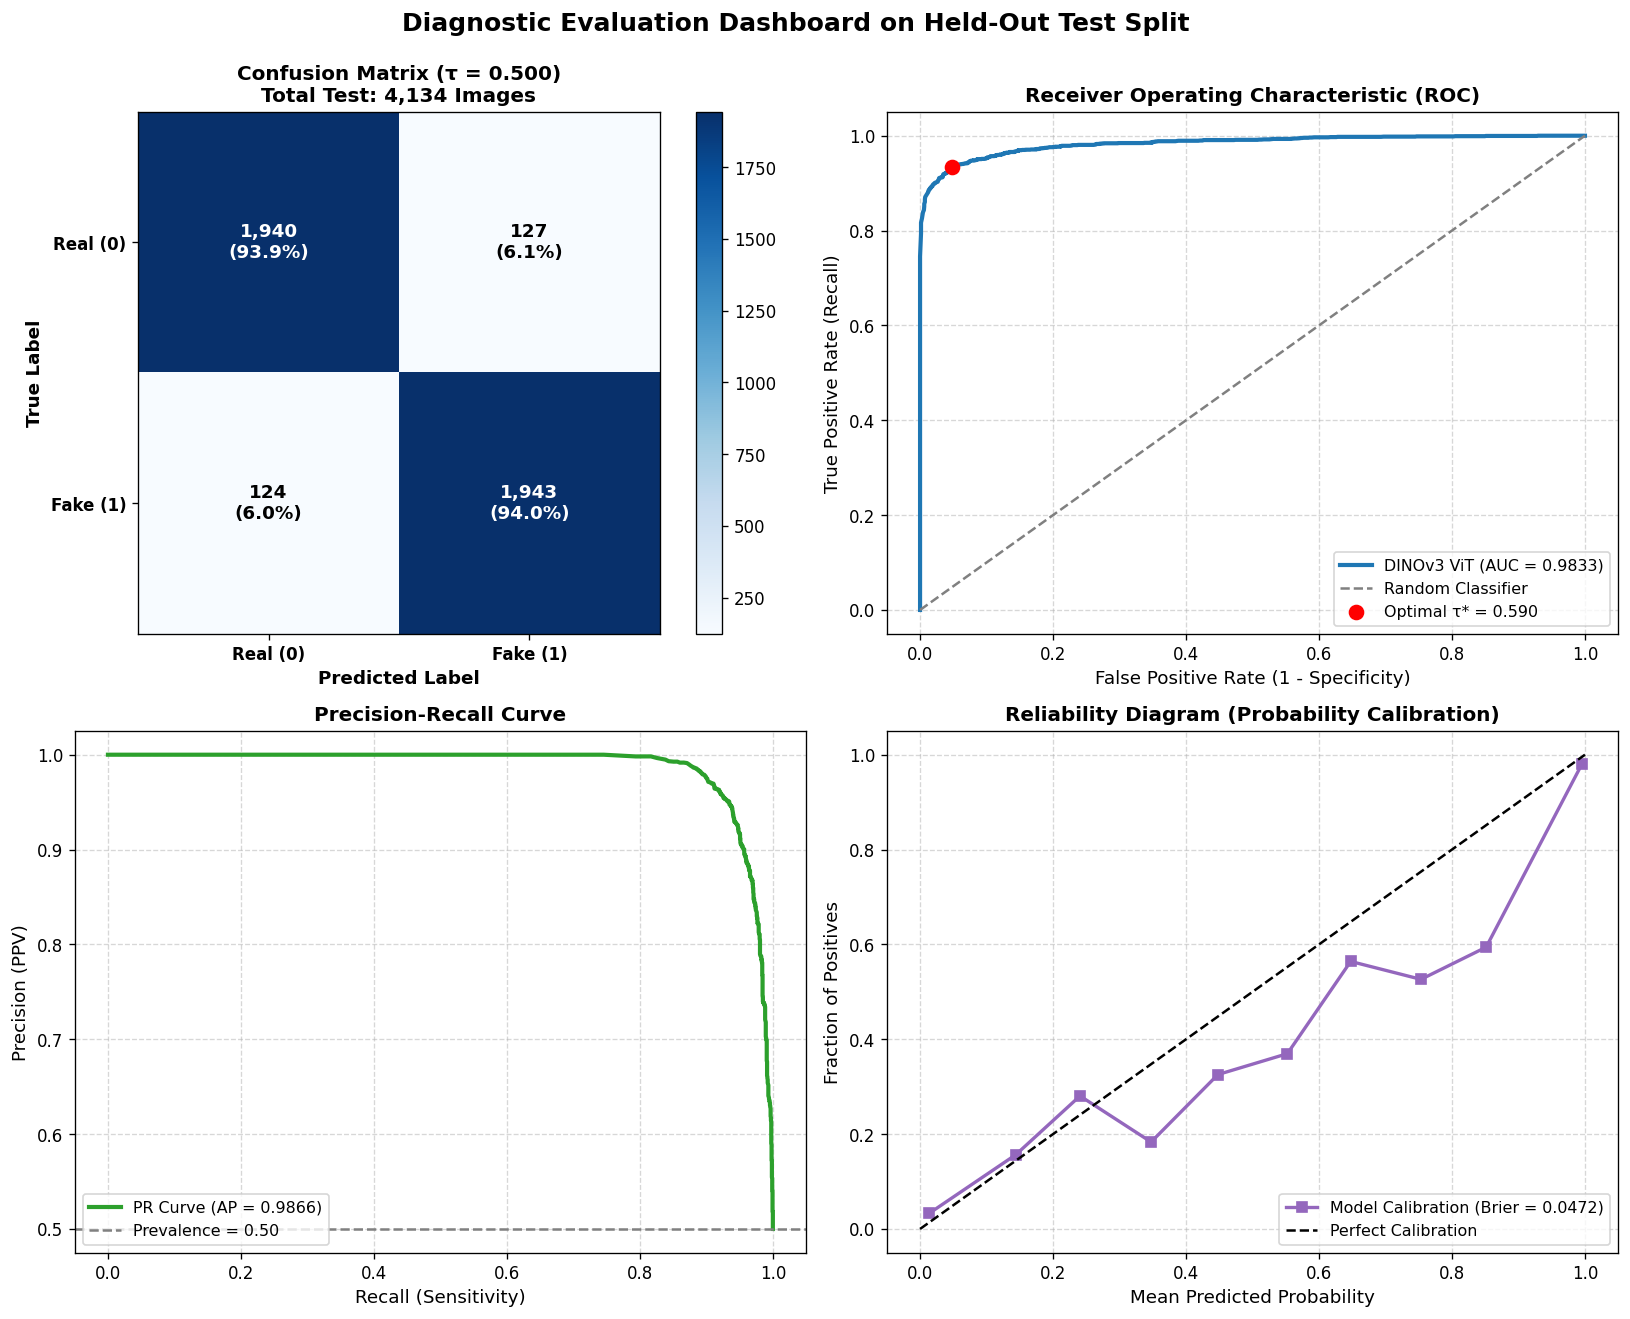

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# Panel 1: Confusion Matrix
cm = confusion_matrix(y_true, y_pred_def)
im0 = axes[0, 0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
axes[0, 0].set_title(f'Confusion Matrix (\u03c4 = 0.500)\nTotal Test: {len(y_true):,} Images', fontweight='bold')
fig.colorbar(im0, ax=axes[0, 0])
tick_marks = np.arange(2)
axes[0, 0].set_xticks(tick_marks); axes[0, 0].set_xticklabels(['Real (0)', 'Fake (1)'], fontweight='bold')
axes[0, 0].set_yticks(tick_marks); axes[0, 0].set_yticklabels(['Real (0)', 'Fake (1)'], fontweight='bold')
axes[0, 0].set_ylabel('True Label', fontweight='bold')
axes[0, 0].set_xlabel('Predicted Label', fontweight='bold')

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0, 0].text(j, i, f"{cm[i, j]:,}\n({cm[i, j]/cm[i].sum()*100:.1f}%)",
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black",
                        fontweight='bold', fontsize=11)

# Panel 2: ROC Curve
axes[0, 1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'DINOv3 ViT (AUC = {test_results["roc_auc"]:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
axes[0, 1].scatter(fpr[opt_idx], tpr[opt_idx], color='red', s=70, zorder=5, label=f'Optimal \u03c4* = {tau_opt:.3f}')
axes[0, 1].set_title('Receiver Operating Characteristic (ROC)', fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate (1 - Specificity)'); axes[0, 1].set_ylabel('True Positive Rate (Recall)')
axes[0, 1].grid(True, linestyle='--', alpha=0.5); axes[0, 1].legend(loc='lower right')

# Panel 3: Precision-Recall Curve
prec_curve, rec_curve, _ = precision_recall_curve(y_true, y_prob)
axes[1, 0].plot(rec_curve, prec_curve, color='#2ca02c', lw=2.5, label=f'PR Curve (AP = {pr_auc:.4f})')
axes[1, 0].axhline(y=y_true.mean(), color='gray', linestyle='--', label=f'Prevalence = {y_true.mean():.2f}')
axes[1, 0].set_title('Precision-Recall Curve', fontweight='bold')
axes[1, 0].set_xlabel('Recall (Sensitivity)'); axes[1, 0].set_ylabel('Precision (PPV)')
axes[1, 0].grid(True, linestyle='--', alpha=0.5); axes[1, 0].legend(loc='lower left')

# Panel 4: Calibration Curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=10)
axes[1, 1].plot(prob_pred, prob_true, 's-', color='#9467bd', lw=2, label=f'Model Calibration (Brier = {brier:.4f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', label='Perfect Calibration')
axes[1, 1].set_title('Reliability Diagram (Probability Calibration)', fontweight='bold')
axes[1, 1].set_xlabel('Mean Predicted Probability'); axes[1, 1].set_ylabel('Fraction of Positives')
axes[1, 1].grid(True, linestyle='--', alpha=0.5); axes[1, 1].legend(loc='lower right')

plt.suptitle('Diagnostic Evaluation Dashboard on Held-Out Test Split', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'balanced_test_diagnostics.png', bbox_inches='tight', dpi=150)
plt.show()

## 10. Per-Method Breakdown Across 40 Deepfake Algorithms

We evaluate detection accuracy across all **40 deepfake generation algorithms**:
- **31 Seen Manipulation Methods** (present during training).
- **9 Zero-Shot Unseen Methods** (`MidJourney`, `StyleCLIP`, `StarGAN-v2`, `CollabDiff`, `HeyGen`, `WhichFaceIsReal`, `DeepFaceLab`, `E4E`, `StarGAN`).

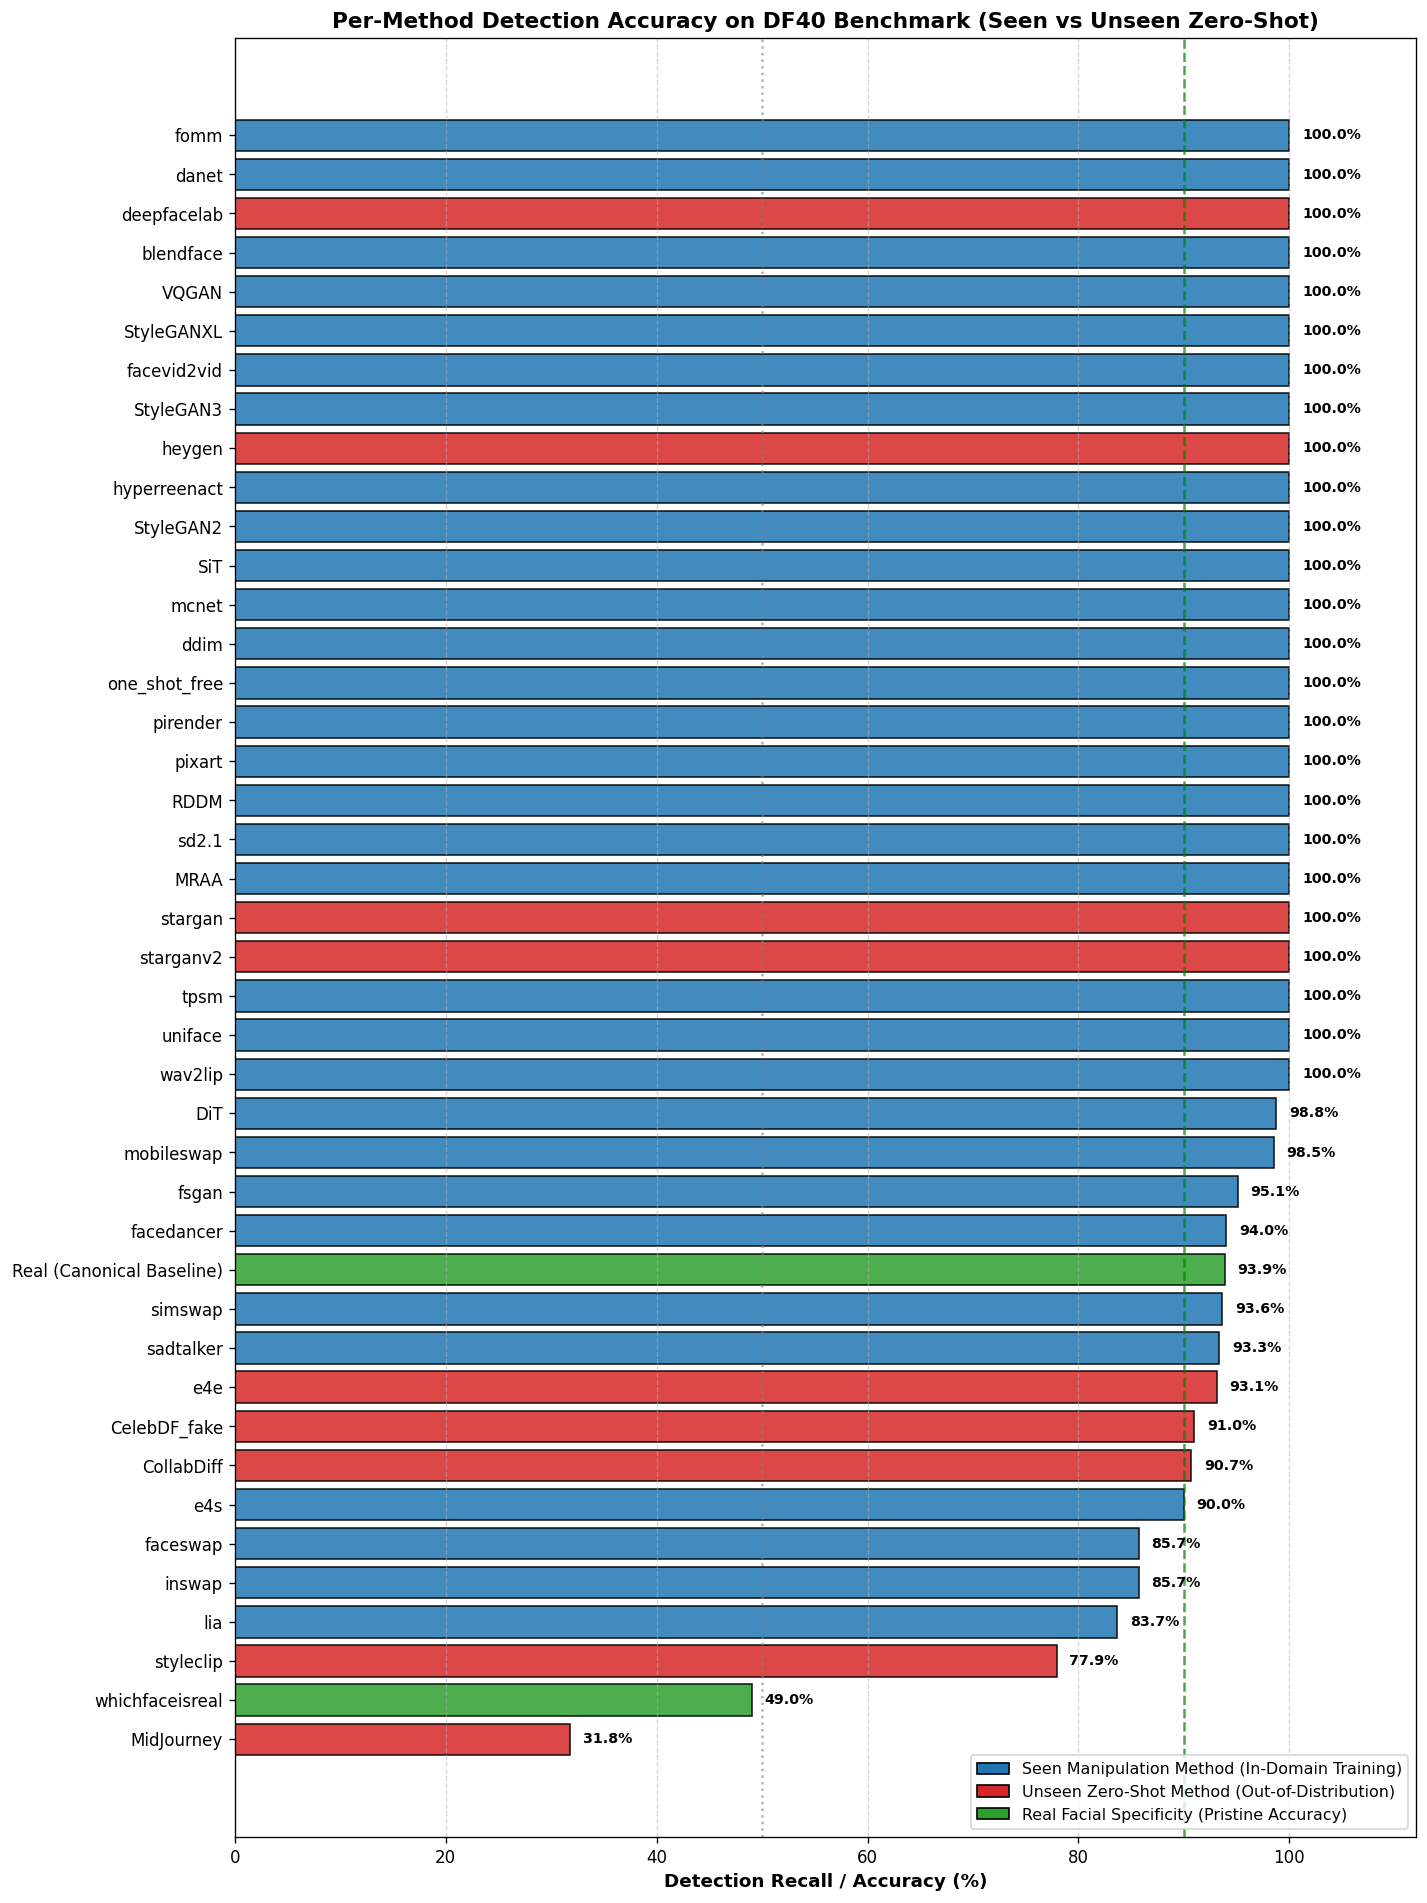

In [44]:
# Per-Method Detection Accuracy on DF40 Benchmark
df_pred = pd.read_csv(PROJECT_ROOT / "experiments" / "results" / "test_balanced_predictions.csv")

UNSEEN_METHODS = {
    'collabdiff', 'deepfacelab', 'e4e', 'heygen', 'midjourney',
    'stargan', 'starganv2', 'styleclip', 'whichfaceisreal', 'celebdf_fake', 'celebdfv2'
}

# Calculate detection recall per manipulation algorithm
df_fakes = df_pred[df_pred['true_label'] == 1]
method_results = []
for m_name, g in df_fakes.groupby('method'):
    total_cnt = len(g)
    correct_cnt = int((g['pred'] == 1).sum())
    recall_rate = correct_cnt / total_cnt * 100
    is_unseen = any(u in m_name.lower() for u in UNSEEN_METHODS)
    method_results.append({
        'method': m_name,
        'samples': total_cnt,
        'accuracy': recall_rate,
        'unseen': is_unseen
    })

# Include Real Pristine Specificity
df_reals = df_pred[df_pred['true_label'] == 0]
method_results.append({
    'method': 'Real (Canonical Baseline)',
    'samples': len(df_reals),
    'accuracy': (df_reals['pred'] == 0).sum() / len(df_reals) * 100,
    'unseen': False
})

df_methods = pd.DataFrame(method_results).sort_values(by='accuracy', ascending=True)

# Plot Per-Method Performance
fig, ax = plt.subplots(figsize=(12, max(7, len(df_methods) * 0.38)))
colors = ['#2ca02c' if 'real' in m.lower() else '#d62728' if u else '#1f77b4' for m, u in zip(df_methods['method'], df_methods['unseen'])]

bars = ax.barh(df_methods['method'], df_methods['accuracy'], color=colors, edgecolor='black', alpha=0.85)
ax.set_xlim([0, 112])
ax.set_xlabel('Detection Recall / Accuracy (%)', fontweight='bold', fontsize=11)
ax.set_title('Per-Method Detection Accuracy on DF40 Benchmark (Seen vs Unseen Zero-Shot)', fontsize=13, fontweight='bold')
ax.axvline(x=50, color='gray', linestyle=':', alpha=0.6, label='Random Guess (50%)')
ax.axvline(x=90, color='green', linestyle='--', alpha=0.7, label='Strong Detection (90%)')
ax.grid(axis='x', linestyle='--', alpha=0.5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1f77b4', edgecolor='black', label='Seen Manipulation Method (In-Domain Training)'),
    Patch(facecolor='#d62728', edgecolor='black', label='Unseen Zero-Shot Method (Out-of-Distribution)'),
    Patch(facecolor='#2ca02c', edgecolor='black', label='Real Facial Specificity (Pristine Accuracy)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9.5)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 1.2, bar.get_y() + bar.get_height()/2., f"{w:.1f}%", ha='left', va='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'per_method_accuracy_balanced.png', bbox_inches='tight', dpi=150)
plt.show()

## 11. In-Depth Error Analysis & Misclassification Gallery

We dissect failure modes (False Negatives where fakes were missed, and False Positives where real faces were flagged as fakes) and generate a qualitative gallery for inspection.

🚨 ERROR ANALYSIS SUMMARY (HELD-OUT TEST SPLIT)
Total Test Images:        4,134
Total Misclassifications: 251 (6.07% Error Rate)
  - False Negatives (Missed Fakes): 124 (6.00% of all Fakes)
  - False Positives (False Alarms): 127 (6.14% of all Reals)

🔍 Top False Negative Sources (Methods with Most Missed Deepfakes):


,method,Missed_Fakes_Count
3,MidJourney,30
15,whichfaceisreal,26
14,styleclip,15
0,CelebDF_fake,11
10,lia,8
7,faceswap,7
1,CollabDiff,4
4,e4e,4
9,inswap,4
6,facedancer,3


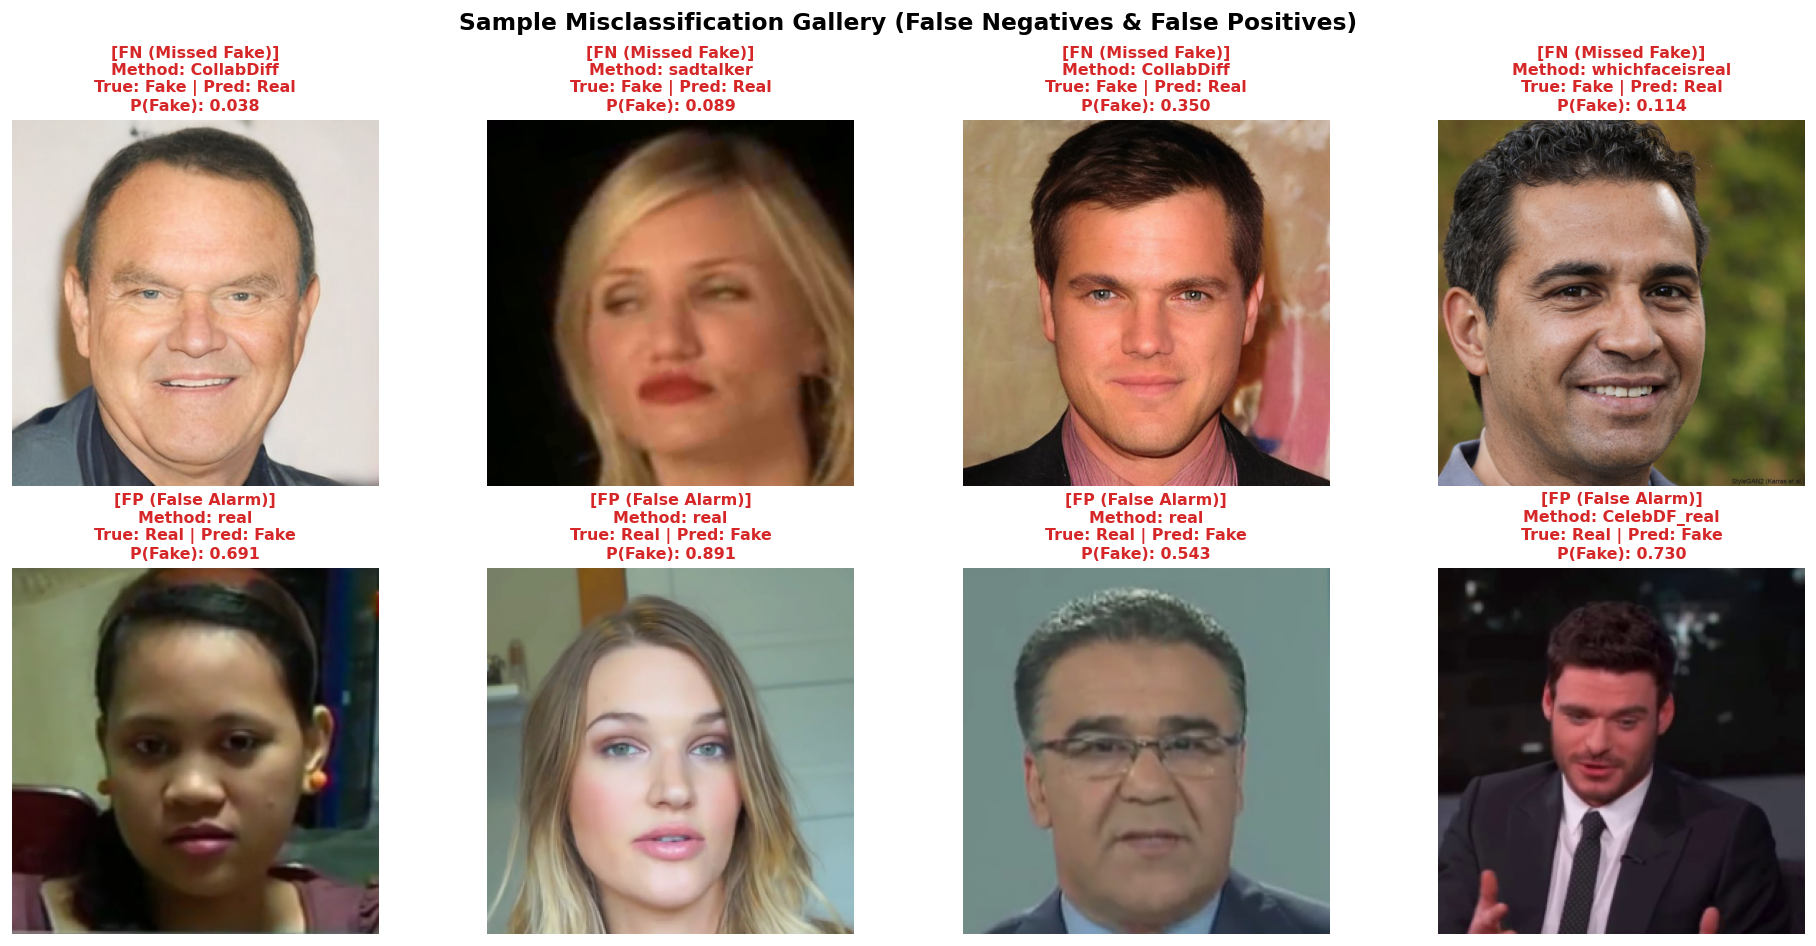

In [45]:
# Load predictions and inspect error cases
results_df = pd.read_csv(PROJECT_ROOT / "experiments" / "results" / "test_balanced_predictions.csv")

total_test = len(results_df)
total_errors = int(results_df["is_error"].sum())
fn_df = results_df[(results_df["true_label"] == 1) & (results_df["pred"] == 0)]
fp_df = results_df[(results_df["true_label"] == 0) & (results_df["pred"] == 1)]

print("=" * 70)
print("🚨 ERROR ANALYSIS SUMMARY (HELD-OUT TEST SPLIT)")
print("=" * 70)
print(f"Total Test Images:        {total_test:,}")
print(f"Total Misclassifications: {total_errors:,} ({total_errors/total_test*100:.2f}% Error Rate)")
print(f"  - False Negatives (Missed Fakes): {len(fn_df):,} ({len(fn_df)/max(1, (results_df['true_label']==1).sum())*100:.2f}% of all Fakes)")
print(f"  - False Positives (False Alarms): {len(fp_df):,} ({len(fp_df)/max(1, (results_df['true_label']==0).sum())*100:.2f}% of all Reals)")

print("\n🔍 Top False Negative Sources (Methods with Most Missed Deepfakes):")
fn_by_method = fn_df.groupby("method").size().reset_index(name="Missed_Fakes_Count").sort_values(by="Missed_Fakes_Count", ascending=False)
display(fn_by_method.head(10))

# Qualitative Gallery: Display 8 Misclassified Cases
fn_samples = fn_df.head(4)
fp_samples = fp_df.head(4)
gallery_samples = pd.concat([fn_samples, fp_samples]).reset_index(drop=True)

if len(gallery_samples) > 0:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for idx, row in gallery_samples.iterrows():
        ax = axes[idx // 4, idx % 4]
        try:
            img = Image.open(row["path"]).convert("RGB")
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "Image Load Error", ha="center", va="center")
            
        true_str = "Fake" if row["true_label"] == 1 else "Real"
        pred_str = "Fake" if row["pred"] == 1 else "Real"
        err_type = "FN (Missed Fake)" if row["true_label"] == 1 else "FP (False Alarm)"
        
        ax.set_title(f"[{err_type}]\nMethod: {row['method']}\nTrue: {true_str} | Pred: {pred_str}\nP(Fake): {row['prob_fake']:.3f}", fontsize=9.5, fontweight="bold", color="#d62728")
        ax.axis("off")
        
    plt.suptitle("Sample Misclassification Gallery (False Negatives & False Positives)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "misclassified_gallery.png", bbox_inches="tight", dpi=150)
    plt.show()

## 12. Multi-Head Self-Attention Map Visualization (CLS Attention)

We extract the Multi-Head Self-Attention matrix from the last transformer block of the DINOv3 ViT backbone to inspect which facial regions (eyes, mouth, boundary seams) the model focuses on.

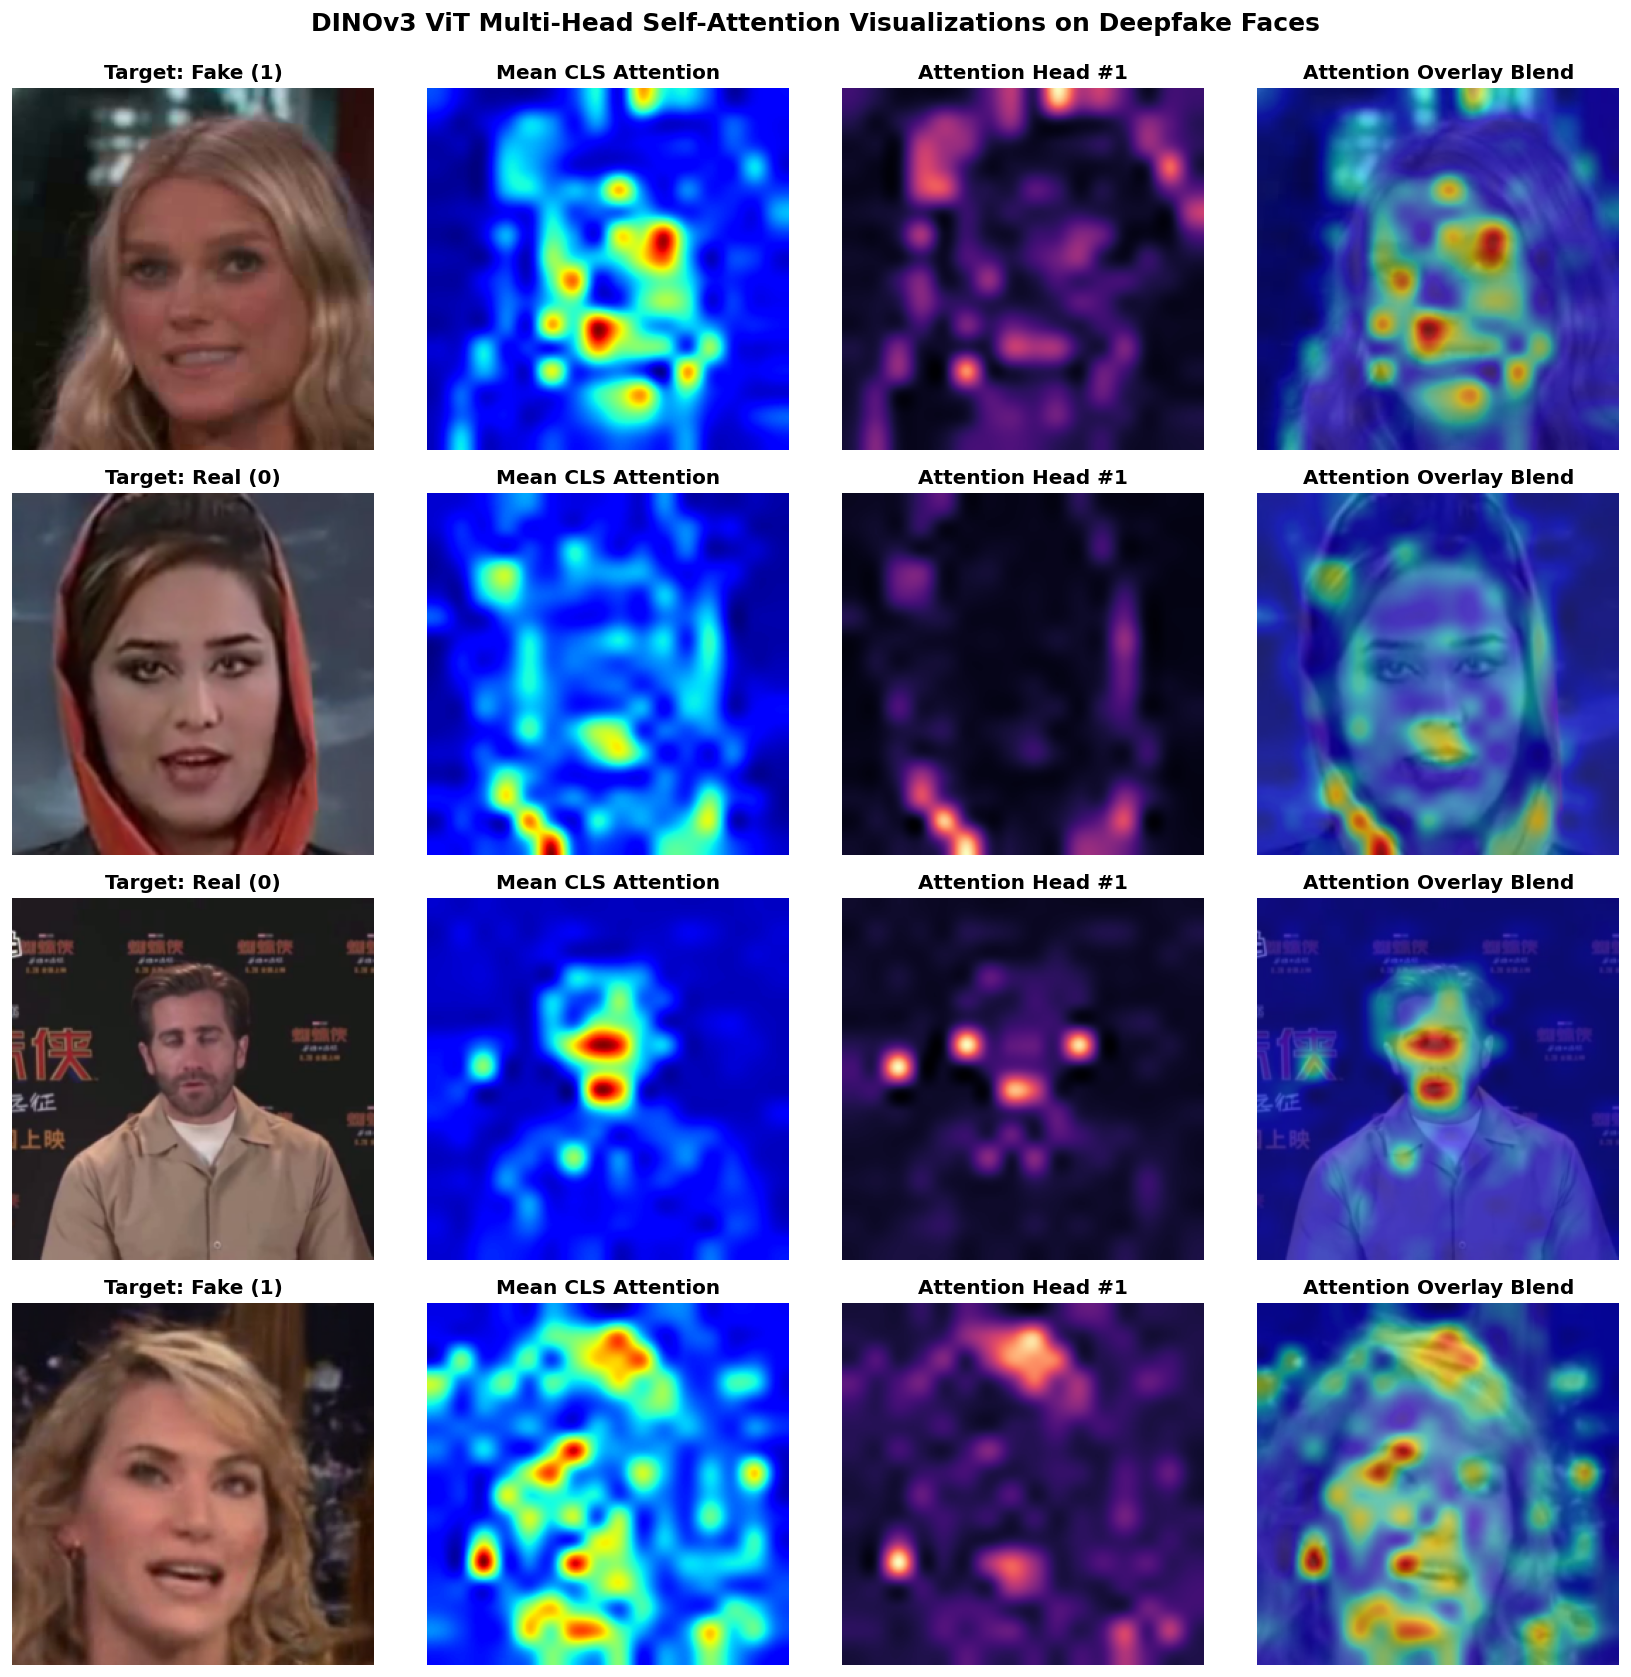

In [46]:
@torch.no_grad()
def extract_attention_map(model, img_tensor, device):
    """Extract self-attention map from the last transformer block of DINOv3 ViT."""
    model.eval()
    x = img_tensor.unsqueeze(0).to(device)  # (1, 3, 256, 256)
    
    # Forward through backbone to populate Attention.attn
    _ = model.backbone(x)
    
    # Get attention tensor from the last block: shape (1, num_heads, N, N)
    last_block_attn = model.backbone.layer[-1].attention.attn
    
    prefix_tokens = 5  # 1 CLS + 4 register tokens
    num_patches_side = IMG_SIZE // 16  # 16x16
    
    # CLS attention to patch tokens
    cls_attn = last_block_attn[0, :, 0, prefix_tokens:]
    cls_attn_grid = cls_attn.float().reshape(-1, num_patches_side, num_patches_side).cpu().numpy()
    
    # Average across heads
    mean_attn = cls_attn_grid.mean(axis=0)
    mean_attn = (mean_attn - mean_attn.min()) / (mean_attn.max() - mean_attn.min() + 1e-8)
    return mean_attn, cls_attn_grid

# Select 4 test samples (2 Real, 2 Fake)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
sample_indices = [0, 1, 2, 3]

for row, idx in enumerate(sample_indices):
    img_path, lbl = test_dataset.samples[idx]
    raw_img = Image.open(img_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    img_t = eval_transform(raw_img)
    
    mean_attn, head_attns = extract_attention_map(model, img_t, device)
    attn_resized = np.array(Image.fromarray(mean_attn).resize((IMG_SIZE, IMG_SIZE), resample=Image.BICUBIC))
    
    # Column 1: Original Image
    axes[row, 0].imshow(raw_img)
    axes[row, 0].set_title(f"Target: {'Fake (1)' if lbl==1 else 'Real (0)'}", fontweight='bold')
    axes[row, 0].axis('off')
    
    # Column 2: Mean Attention Heatmap
    axes[row, 1].imshow(attn_resized, cmap='jet')
    axes[row, 1].set_title('Mean CLS Attention', fontweight='bold')
    axes[row, 1].axis('off')
    
    # Column 3: Head #0 Attention
    head0_resized = np.array(Image.fromarray(head_attns[0]).resize((IMG_SIZE, IMG_SIZE), resample=Image.BICUBIC))
    axes[row, 2].imshow(head0_resized, cmap='magma')
    axes[row, 2].set_title('Attention Head #1', fontweight='bold')
    axes[row, 2].axis('off')
    
    # Column 4: Overlay
    axes[row, 3].imshow(raw_img)
    axes[row, 3].imshow(attn_resized, cmap='jet', alpha=0.55)
    axes[row, 3].set_title('Attention Overlay Blend', fontweight='bold')
    axes[row, 3].axis('off')

plt.suptitle('DINOv3 ViT Multi-Head Self-Attention Visualizations on Deepfake Faces', fontsize=15, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(ATTENTION_PLOTS_DIR / 'vit_cls_attention_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

## 13. Experiment Summary, Artifact Export & Conclusion

We consolidate all experiment metadata, hyperparameters, best validation metrics, test benchmark scores, and optimal threshold into a standardized JSON report saved in `experiments/results/`.

In [47]:
# Consolidate experiment metadata and export to JSON
summary_report = {
    'experiment_name': 'dinov3_vit_domain_balanced_finetuning',
    'timestamp': TIMESTAMP_STR,
    'model_architecture': 'DINOv3 ViT-Small/16 (22.0M parameters)',
    'training_protocol': {
        'epochs': EPOCHS,
        'batch_size': BATCH_SIZE,
        'base_lr': BASE_LR,
        'head_lr': HEAD_LR,
        'llrd_decay_rate': 0.80,
        'label_smoothing': LABEL_SMOOTHING,
        'domain_balanced_dataset': True,
        'train_samples': len(train_dataset),
        'val_samples': len(val_dataset),
        'test_samples': len(test_dataset)
    },
    'best_validation_metrics': {
        'best_val_auc': float(best_val_auc)
    },
    'held_out_test_metrics': {
        'default_threshold_0.5': {
            'accuracy': float(accuracy_score(y_true, y_pred_def)),
            'precision': float(precision_score(y_true, y_pred_def)),
            'recall': float(recall_score(y_true, y_pred_def)),
            'specificity': float(spec_def),
            'f1_score': float(f1_score(y_true, y_pred_def)),
            'roc_auc': float(test_results['roc_auc']),
            'pr_auc': float(pr_auc),
            'brier_score': float(brier)
        },
        'optimal_threshold': {
            'threshold_tau': float(tau_opt),
            'accuracy': float(accuracy_score(y_true, y_pred_opt)),
            'precision': float(precision_score(y_true, y_pred_opt)),
            'recall': float(recall_score(y_true, y_pred_opt)),
            'specificity': float(spec_opt),
            'f1_score': float(f1_score(y_true, y_pred_opt))
        }
    },
    'artifacts': {
        'best_checkpoint': str(GLOBAL_BEST_CKPT),
        'last_checkpoint': str(GLOBAL_LAST_CKPT),
        'test_predictions_csv': str(PROJECT_ROOT / "experiments" / "results" / "test_balanced_predictions.csv"),
        'plots_directory': str(PLOTS_DIR)
    }
}

summary_json_path = PROJECT_ROOT / "experiments" / "results" / "finetune_report.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary_report, f, indent=2)

print(f"✅ Experiment summary report exported to: {summary_json_path}")
print("\n" + "="*70)
print("🎉 DINOv3 ViT BALANCED DEEPFAKE DETECTION PIPELINE COMPLETE!")
print("="*70)

✅ Experiment summary report exported to: /workspace/hoangtuan/deepfake-ViT/experiments/results/finetune_report.json

🎉 DINOv3 ViT BALANCED DEEPFAKE DETECTION PIPELINE COMPLETE!
